In [1]:
# import the important library
import os
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [22]:
import matplotlib.patches as mpatches

In [4]:
import openpyxl

In [2]:
# Load the expr data, since ID_REF is a column set as index
expr=pd.read_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\04_expr_clean.csv", index_col=0)
expr.head()

,GSM1160723,GSM1160724,GSM1160725,GSM1160726,GSM1160727,GSM1160728,GSM1160729,GSM1160730,GSM1160731,GSM1160732,...,GSM1160884,GSM1160885,GSM1160886,GSM1160887,GSM1160888,GSM1160889,GSM1160890,GSM1160891,GSM1160892,GSM1160893
ID_REF,,,,,,,,,,,,,,,,,,,,,
A1BG,5.74584,6.12052,6.20084,6.26834,5.97488,6.19885,6.19416,5.91354,6.50261,6.00442,...,5.00284,5.23040,4.71726,4.69979,5.08348,5.03506,4.82434,4.83385,4.28362,5.13701
A1CF,4.28961,3.96765,4.03272,4.20885,3.96768,4.17360,4.45578,4.15376,4.28599,4.28108,...,3.53385,3.33004,3.13325,3.26612,3.26458,3.29670,3.87953,3.11349,4.00958,3.63878
A2M,4.26153,4.36282,4.29775,4.07853,4.13649,4.50724,4.68458,4.52090,4.69896,4.31869,...,3.33608,3.17635,3.44556,3.14678,8.34015,8.43369,4.18721,5.28860,3.14168,3.41457
A2ML1,4.37891,4.69267,4.78660,4.72511,4.92029,4.97234,4.40873,4.60817,5.04669,4.87182,...,3.99649,3.97625,3.91210,3.61199,3.81501,4.30799,4.48527,3.51901,3.97556,3.81770
A3GALT2,4.87398,4.92492,5.10070,4.88890,4.87332,5.11453,4.55024,4.83310,4.99127,5.34506,...,3.85784,3.92446,4.31817,3.95839,3.93316,4.15178,4.14666,3.82942,4.12997,3.80581


In [3]:
# Laod the pheno table with GSM as true index
pheno=pd.read_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\05_pheno_clean.csv", index_col=0)
pheno.head()

,title,characteristics,cell_line,treatment
gsm,,,,
GSM1160723,HeyA8-(1),"['cell line: HeyA8', 'cell type: ovarian cance...",HeyA8,control
GSM1160724,HeyA8-(1)b,"['cell line: HeyA8', 'cell type: ovarian cance...",HeyA8,control
GSM1160725,HeyA8-(2),"['cell line: HeyA8', 'cell type: ovarian cance...",HeyA8,control
GSM1160726,HeyA8-(2)b,"['cell line: HeyA8', 'cell type: ovarian cance...",HeyA8,control
GSM1160727,HeyA8-(3),"['cell line: HeyA8', 'cell type: ovarian cance...",HeyA8,control


In [5]:
# Load the supplementary table 1
suppl=pd.read_excel(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Data\Raw\supplementary_table_1.xlsx")
suppl.head()

,Index,Sample,Classification,Molecular Subtype,"TP53 (Mutant=1,Wild Type=0)",MTS GI50 (M),BrdU IC50 (M),Caspase3 EC50 (M),Histology,Original Repository,Catalogue Number,Source,Reference
0,1,OVCA 429,Epithelial-like,Epi-A,0,83.54 x 10-6,19.22 x 10-6,37.31 x 10-6,Serous,---,---,Kyoto U.,"Bast RC Jr, Feeney M, Lazarus H, Nadler LM, Co..."
1,2,OVCA 420,Epithelial-like,Stem-B,1,43.07 x 10-6,5.55 x 10-6,5.25 x 10-6,Serous,---,---,Kyoto U.,"Bast RC Jr, Feeney M, Lazarus H, Nadler LM, Co..."
2,3,OVCA 433,Epithelial-like,Epi-A,0,201.98 x 10-6,22.90 x 10-6,80.94 x 10-6,Papillary serous cystadenocarcinoma,---,---,Kyoto U.,"Bast RC Jr, Feeney M, Lazarus H, Nadler LM, Co..."
3,4,TAYA,Epithelial-like,Epi-A,1,28.69 x 10-6,---,---,Clear cell carcinoma,Jichi Medical University,---,Kyoto U.,"Saga Y, Suzuki M, Machida S, Ohwada M, Sato I...."
4,5,OVCAR-8,Epithelial-like,Epi-A,1,33.12 x 10-6,4.86 x 10-6,5.85 x 10-6,Undifferentiated,NCI-Frederick,---,Kyoto U.,"Schilder RJ, Hall L, Monks A, Handel LM, Forna..."


In [8]:
# Parse accurate cell line names from characteristics
pheno["cell_line"] = (
    pheno["characteristics"]
    .str.extract(r"cell line:\s*([^,']+)", expand=False)
    .str.strip()
)
pheno["cell_line_matched"] = pheno["cell_line"].replace(
    {"DOV13A": "DOV 13", "DOV13B": "DOV 13"}
)


# Parse GI50 numeric values
def parse_gi50(val):
  if pd.isna(val) or str(val).strip() in ["---", "", "nan"]:
    return np.nan
  s = (
      str(val)
      .strip()
      .replace(" ", "")
      .replace("x10-", "e-")
      .replace("x10^-", "e-")
  )
  try:
    return float(s)
  except ValueError:
    return np.nan


suppl["GI50"] = suppl["MTS GI50 (M)"].apply(parse_gi50)


# Standardize names for joining
def normalize(name):
  return (
      str(name).strip().upper().replace(" ", "").replace("-", "").replace("_", "")
  )


suppl["norm_key"] = suppl["Sample"].apply(normalize)
pheno["norm_key"] = pheno["cell_line_matched"].apply(normalize)

supp_lookup = (
    suppl.dropna(subset=["GI50"])
    .drop_duplicates("norm_key")
    .set_index("norm_key")[["Sample", "Molecular Subtype", "GI50"]]
)

# Merge and explicitly set 'gsm' column as index
pheno = (
    pheno.reset_index()
    .merge(supp_lookup, left_on="norm_key", right_index=True, how="left")
    .set_index("gsm")
)

# Save the merged pheno table
pheno.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\06_pheno_merged.csv")

In [ ]:

# Filter for untreated baseline control samples that have a measured GI50
baseline_samples = pheno[
    (pheno["treatment"] == "control") & (pheno["GI50"].notna())
]

# Ensure GSM IDs match the expression matrix columns
valid_samples = [gsm for gsm in baseline_samples.index if gsm in expr.columns]
baseline_samples = baseline_samples.loc[valid_samples]
baseline_expr = expr[valid_samples]

print(
    f"Matched {len(valid_samples)} baseline control samples across"
    f" {baseline_samples['cell_line'].nunique()} cell lines."
)

# Average biological and technical replicates per cell line
baseline_expr_T = baseline_expr.T
baseline_expr_T["cell_line"] = baseline_samples.loc[
    baseline_expr_T.index, "cell_line"
].values
baseline_avg = baseline_expr_T.groupby("cell_line").mean()

# Align supplementary metadata with aggregated cell lines
baseline_meta = (
    baseline_samples.groupby("cell_line")[["GI50", "Molecular Subtype"]]
    .first()
    .loc[baseline_avg.index]
)
baseline_meta["logGI50"] = np.log2(baseline_meta["GI50"])

# Save complete baseline matrices (useful for WGCNA in Stage 3)
baseline_avg.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\07_baseline_expr_all.csv")
baseline_meta.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\08_baseline_meta_all.csv")

Matched 72 baseline control samples across 30 cell lines.


In [ ]:
# Tertile split: resistant (top third GI50) vs sensitive (bottom third) for DEG
q1, q2 = baseline_meta["GI50"].quantile([1 / 3, 2 / 3])
baseline_meta["group"] = pd.cut(
    baseline_meta["GI50"], bins=[-np.inf, q1, q2, np.inf],
    labels=["sensitive", "intermediate", "resistant"]
)
keep = baseline_meta["group"].isin(["sensitive", "resistant"])
X_deg = baseline_avg.loc[keep[keep].index]
y_deg = baseline_meta.loc[keep[keep].index, "group"]

X_deg.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\09_X_deg.csv")
y_deg.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\10_y_deg.csv")

In [13]:
# DEG test: Mann-Whitney U + Benjamini-Hochberg 
resistant_vals = X_deg[y_deg == "resistant"]
sensitive_vals = X_deg[y_deg == "sensitive"]

pvals, logfc = [], []
for gene in X_deg.columns:
    _, p = stats.mannwhitneyu(resistant_vals[gene], sensitive_vals[gene],
                               alternative="two-sided")
    pvals.append(p)
    logfc.append(resistant_vals[gene].mean() - sensitive_vals[gene].mean())

deg_table = pd.DataFrame({"gene": X_deg.columns, "logFC": logfc, "pval": pvals})
deg_table["adj_p"] = multipletests(deg_table["pval"], method="fdr_bh")[1]
deg_table["neg_log10_adj_p"] = -np.log10(deg_table["adj_p"].clip(lower=1e-300))

sig_degs = deg_table[(deg_table["pval"] < 0.01) & (deg_table["logFC"].abs() > 0.58)]
sig_degs.to_csv(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Tables\11_DEGs_resistant_vs_sensitive.csv", index=False)
print(f"Significant DEGs: {len(sig_degs)} / {len(deg_table)} genes tested")

Significant DEGs: 248 / 23303 genes tested


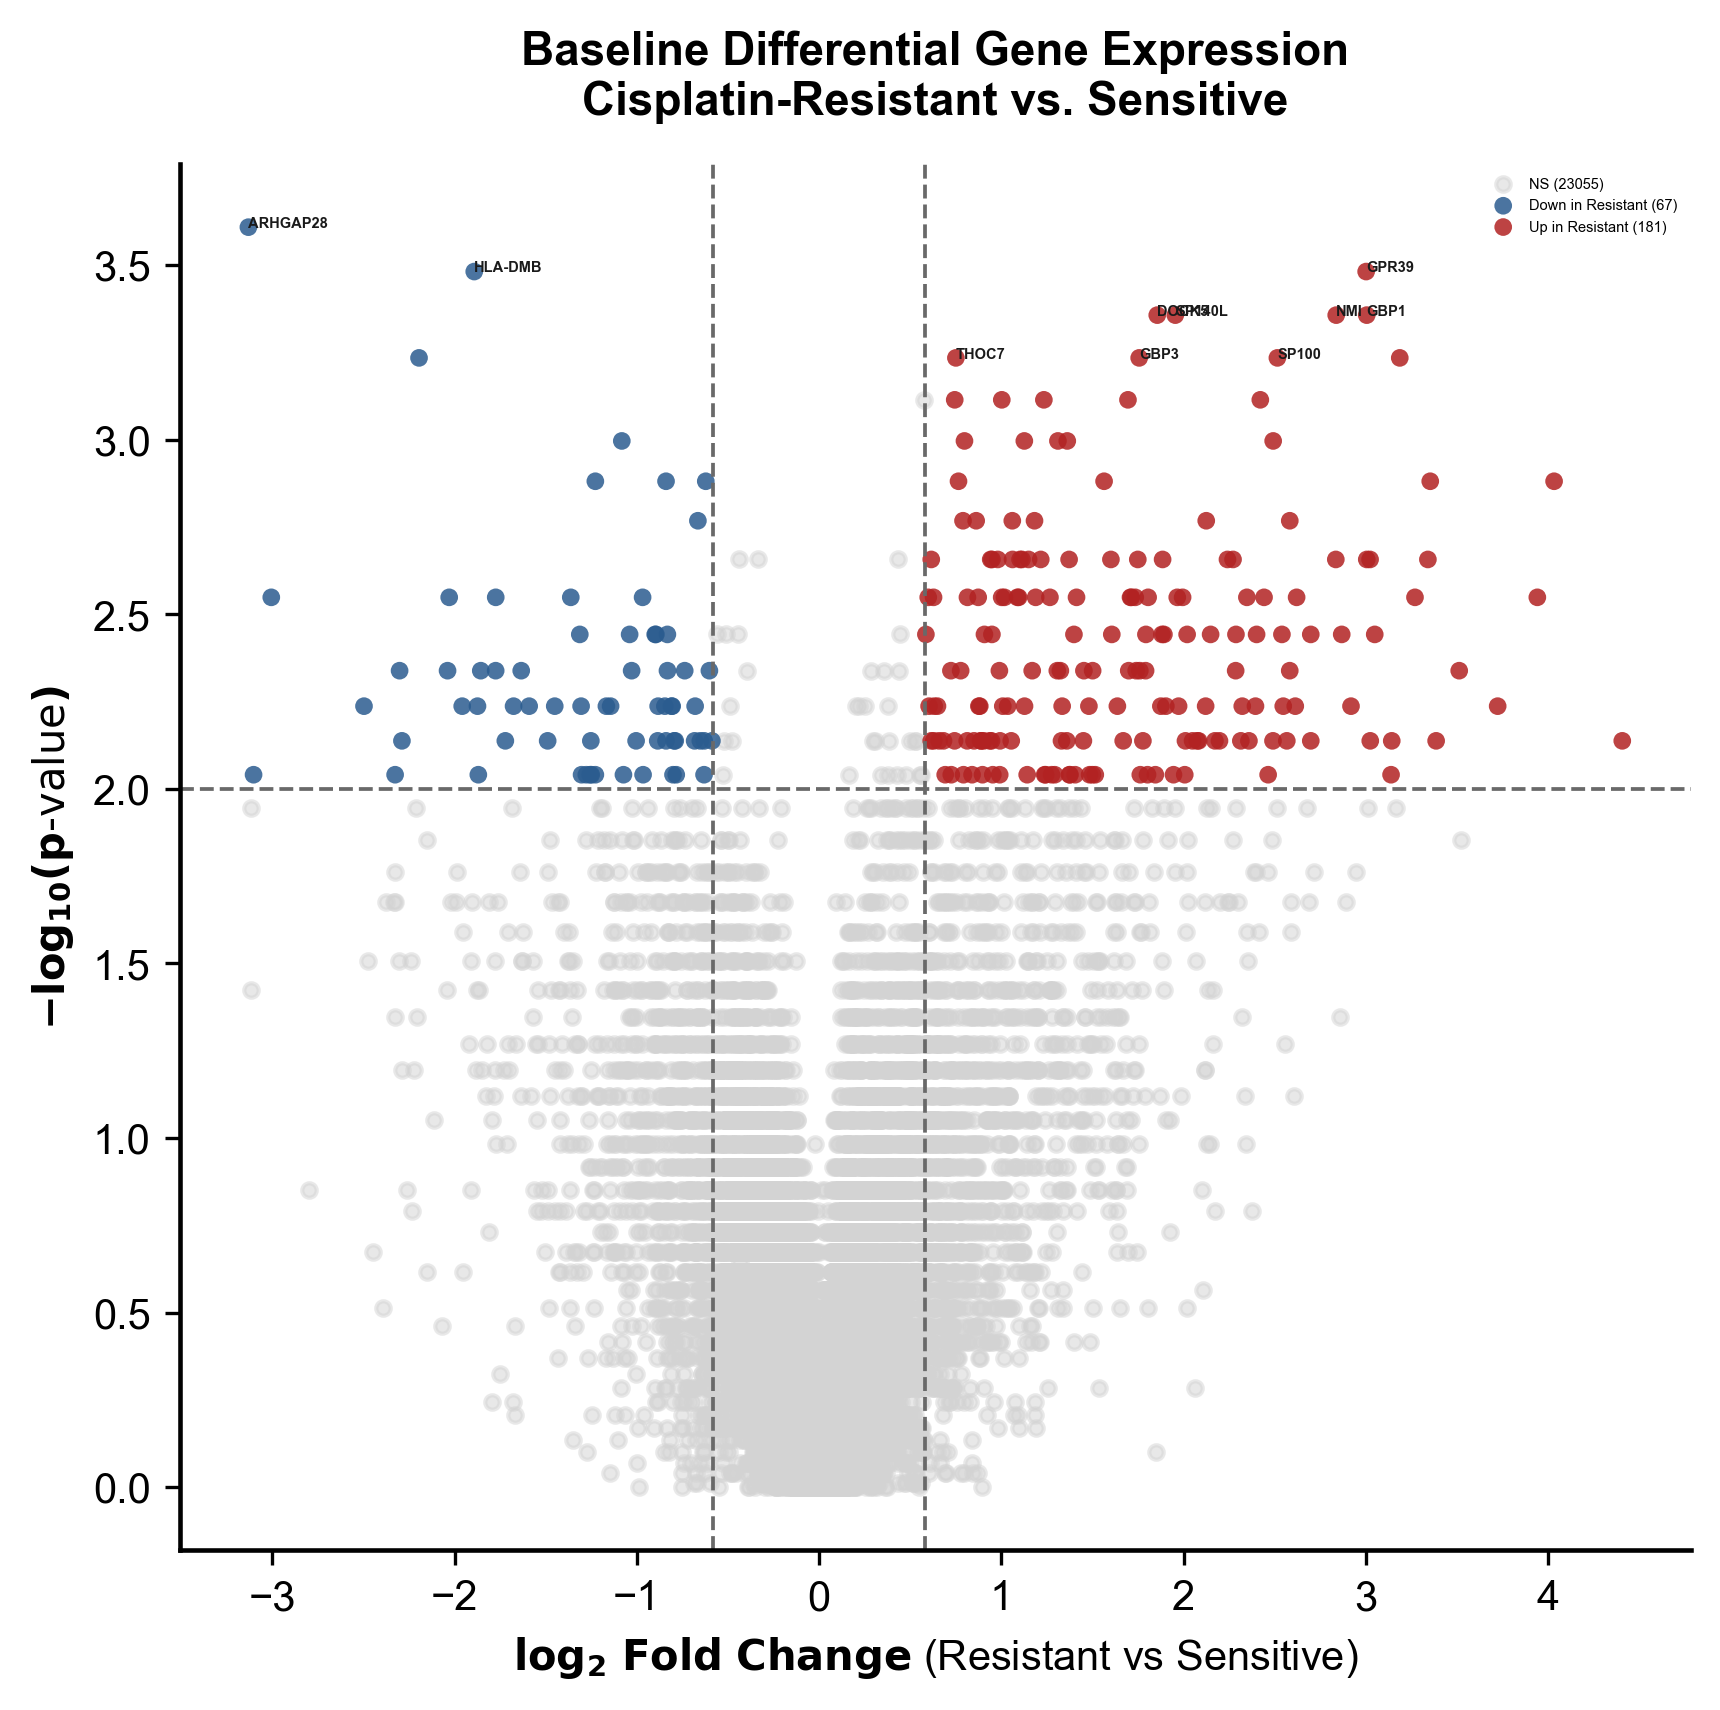

In [19]:
fc_thresh = 0.58  # 1.5-fold change in log2 scale
p_thresh = 0.01  # Raw p-value threshold

# Ensure -log10(pval) is present
deg_table["neg_log10_pval"] = -np.log10(deg_table["pval"].clip(lower=1e-300))

# Classify points
is_up = (deg_table["pval"] < p_thresh) & (deg_table["logFC"] >= fc_thresh)
is_down = (deg_table["pval"] < p_thresh) & (deg_table["logFC"] <= -fc_thresh)
is_ns = ~(is_up | is_down)

deg_table["status"] = "Not Significant"
deg_table.loc[is_up, "status"] = f"Up in Resistant ({is_up.sum()})"
deg_table.loc[is_down, "status"] = f"Down in Resistant ({is_down.sum()})"


# Publication ready plots

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.linewidth": 1.1,
})

fig, ax = plt.subplots(figsize=(6.5, 6), dpi=300)

# Plot non-significant points first in the background
ax.scatter(
    deg_table.loc[is_ns, "logFC"],
    deg_table.loc[is_ns, "neg_log10_pval"],
    c="#d3d3d3",
    s=12,
    alpha=0.5,
    label=f"NS ({is_ns.sum()})",
    rasterized=True,  # Keeps PDF file sizes small and crisp
)

# Plot Down-regulated
ax.scatter(
    deg_table.loc[is_down, "logFC"],
    deg_table.loc[is_down, "neg_log10_pval"],
    c="#2b5c8f",
    s=18,
    alpha=0.85,
    edgecolors="none",
    label=f"Down in Resistant ({is_down.sum()})",
)

# Up-regulated plots
ax.scatter(
    deg_table.loc[is_up, "logFC"],
    deg_table.loc[is_up, "neg_log10_pval"],
    c="#b22222",
    s=18,
    alpha=0.85,
    edgecolors="none",
    label=f"Up in Resistant ({is_up.sum()})",
)


# Reference Cutoff Lines

ax.axhline(
    -np.log10(p_thresh),
    color="dimgray",
    linestyle="--",
    linewidth=0.9,
    zorder=1,
)
ax.axvline(
    fc_thresh, color="dimgray", linestyle="--", linewidth=0.9, zorder=1
)
ax.axvline(
    -fc_thresh, color="dimgray", linestyle="--", linewidth=0.9, zorder=1
)


# Annotate Top 10 Significant Genes

sig_candidates = deg_table[is_up | is_down].sort_values("pval").head(10)

texts = []
for _, row in sig_candidates.iterrows():
  t = ax.text(
      row["logFC"],
      row["neg_log10_pval"],
      row["gene"],
      fontsize=3.5,
      weight="semibold",
      color="#1a1a1a",
  )
  texts.append(t)


# esthetic Framing, Labels & Legend

ax.set_xlabel(r"$\mathbf{log_2\ Fold\ Change}$ (Resistant vs Sensitive)")
ax.set_ylabel(r"$\mathbf{-log_{10}(p\text{-value})}$")
ax.set_title(
    "Baseline Differential Gene Expression\nCisplatin-Resistant vs."
    " Sensitive",
    pad=12,
    weight="bold",
    fontsize=11,
)

# Clean minimalist spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
leg = ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=3.5,
    loc="upper right",
)
leg.get_frame().set_alpha(0.85)

# save the plot
plt.savefig(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\03_DEG_volcano.png",dpi=1000,bbox_inches="tight")


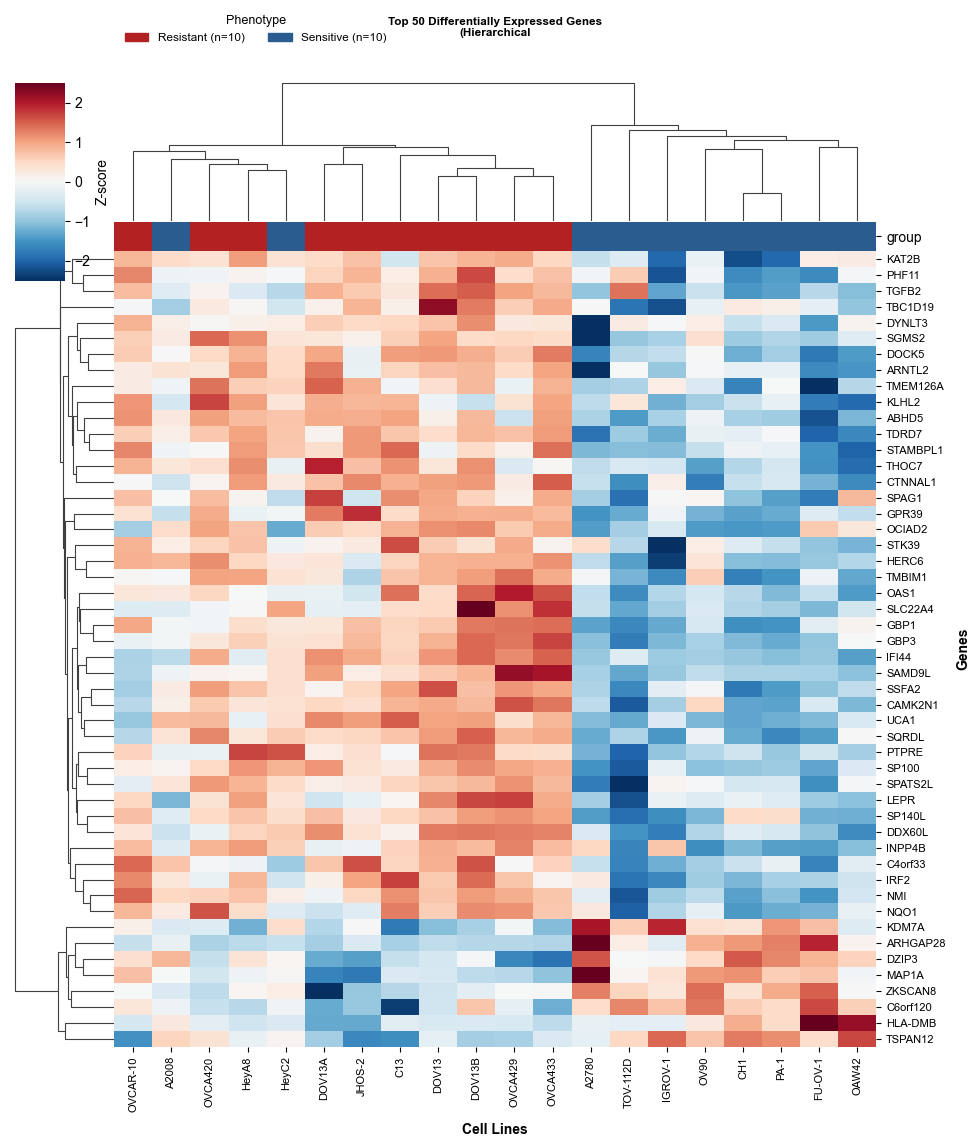

In [ ]:
# Clustered Heatmap of Top DEGs

if len(sig_degs) >= 2:
  top_genes = sig_degs.sort_values("pval")["gene"].head(50).tolist()
else:
  top_genes = deg_table.sort_values("pval")["gene"].head(50).tolist()

if len(top_genes) >= 2:
  heat_data = X_deg[top_genes].T
  heat_z = (
      heat_data.sub(heat_data.mean(axis=1), axis=0)
      .div(heat_data.std(axis=1), axis=0)
      .fillna(0)
  )

  palette_map = {"resistant": "#b22222", "sensitive": "#2b5c8f"}
  col_colors = y_deg.map(palette_map)

  g = sns.clustermap(
      heat_z,
      cmap="RdBu_r",
      center=0,
      vmin=-2.5,
      vmax=2.5,
      col_colors=col_colors,
      xticklabels=True,
      yticklabels=True,
      figsize=(10, max(7, len(top_genes) * 0.22)),
      cbar_kws={"label": "Z-score"},
      dendrogram_ratio=(0.12, 0.15),
      linewidths=0.0,
      tree_kws={"linewidths": 0.8, "colors": "#404040"},
  )

  g.ax_heatmap.set_xticklabels(
      g.ax_heatmap.get_xticklabels(), fontsize=8, rotation=90
  )
  g.ax_heatmap.set_yticklabels(
      g.ax_heatmap.get_yticklabels(), fontsize=8, rotation=0
  )
  g.ax_heatmap.set_xlabel(
      "Cell Lines", fontsize=10, weight="semibold", labelpad=8
  )
  g.ax_heatmap.set_ylabel("Genes", fontsize=10, weight="semibold", labelpad=8)

  # Use mpatches.Patch here
  legend_patches = [
      mpatches.Patch(
          color=color,
          label=f"{group.capitalize()} (n={(y_deg == group).sum()})",
      )
      for group, color in palette_map.items()
  ]
  g.ax_col_dendrogram.legend(
      handles=legend_patches,
      title="Phenotype",
      loc="lower left",
      bbox_to_anchor=(0.0, 1.15),
      ncol=2,
      frameon=False,
      fontsize=8.5,
      title_fontsize=9,
  )

  g.fig.suptitle(
      f"Top {len(top_genes)} Differentially Expressed Genes\n(Hierarchical",
      y=1.04,
      fontsize=8.5,
      weight="bold",
  )

  plt.savefig(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\04_top_DEG_heatmap.png",dpi=1000,bbox_inches="tight")
  


In [ ]:
# Boxplots of Top 10 Individual Genes
# Select top 10 genes by p-value
if len(sig_degs) >= 10:
  top10_df = sig_degs.sort_values("pval").head(10)
else:
  top10_df = deg_table.sort_values("pval").head(10)

top10_genes = top10_df["gene"].tolist()

if top10_genes:
  # 2 rows x 5 columns layout for 10 genes
  fig, axes = plt.subplots(2, 5, figsize=(16, 7), dpi=1000)
  axes_flat = axes.flatten()

  palette = {"resistant": "#b22222", "sensitive": "#2b5c8f"}

  for i, gene in enumerate(top10_genes):
    ax = axes_flat[i]
    plot_df = pd.DataFrame({"expression": X_deg[gene], "group": y_deg})

    # Retrieve stats for the subtitle
    gene_row = top10_df[top10_df["gene"] == gene].iloc[0]
    p_val = gene_row["pval"]
    fc_val = gene_row["logFC"]

    # Boxplot with lighter fill and subtle edges
    sns.boxplot(
        data=plot_df,
        x="group",
        y="expression",
        order=["sensitive", "resistant"],
        palette=palette,
        ax=ax,
        width=0.45,
        boxprops=dict(alpha=0.85),
        fliersize=0,
    )

    # Overlay jittered sample points
    sns.stripplot(
        data=plot_df,
        x="group",
        y="expression",
        order=["sensitive", "resistant"],
        ax=ax,
        color="#222222",
        size=4.5,
        alpha=0.75,
        jitter=0.2,
    )

    # Subplot header with gene name and statistics
    ax.set_title(
        f"{gene}\n$p$ = {p_val:.2e} | $log_2FC$ = {fc_val:.2f}",
        fontsize=9,
        weight="semibold",
        pad=6,
    )
    ax.set_xlabel("")
    ax.set_ylabel(
        r"$\mathbf{log_2\ Expression}$", fontsize=8.5, weight="semibold"
    )
    ax.set_xticklabels(
        ["Sensitive", "Resistant"], fontsize=8.5, weight="medium"
    )
    ax.tick_params(axis="both", which="major", labelsize=8)

    # Minimalist journal spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

  # Hide any unused subplots if fewer than 10 genes are available
  for j in range(len(top10_genes), len(axes_flat)):
    axes_flat[j].set_visible(False)

  fig.suptitle(
      "Top 10 Baseline Differentially Expressed Genes\n(Cisplatin Sensitive vs."
      " Resistant)",
      fontsize=12,
      weight="bold",
      y=1.02,
  )
  
  plt.savefig(r"C:\Users\naemi\Documents\Cis-platin\Cisplatin-Resistant-Ovarian-Cancer-Drug-Discovery\Results\Figures\plots\05_top10_DEG_boxplots.png",dpi=1000,bbox_inches="tight")
  


C:\Users\naemi\AppData\Local\Temp\ipykernel_31236\1571827313.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\naemi\AppData\Local\Temp\ipykernel_31236\1571827313.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\naemi\AppData\Local\Temp\ipykernel_31236\1571827313.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\naemi\AppData\Local\Temp\ipykernel_31236\1571827313.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
C:\Users\naemi\AppData\Local\Tem